# Calories Burnt Prediction System

## Phase 1 - Data Engineering

### Step 1 - Import Required Libraries

In this section, we import the Python libraries required for data manipulation and numerical computations. These libraries will be used throughout the project.

In [0]:
import pandas as pd
import numpy as np

### Step 2: Read the Datasets

The raw datasets are stored inside a Unity Catalog Volume.

In this step, we load both datasets into pandas DataFrames.

In [0]:
exercise = pd.read_csv(
    "/Volumes/databricks00/default/calories_data/exercise(1).csv"
)

calories = pd.read_csv(
    "/Volumes/databricks00/default/calories_data/calories(1).csv"
)

### Step 3: Display Sample Records

Before performing any preprocessing, it is good practice to inspect a few records from each dataset.

In [0]:
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [0]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


### Step 4: Check Dataset Dimensions

The shape of a dataset tells us the number of rows and columns available for analysis.

In [0]:
print(f"Exercise Dataset Shape : {exercise.shape}")
print(f"Calories Dataset Shape : {calories.shape}")

Exercise Dataset Shape : (15000, 8)
Calories Dataset Shape : (15000, 2)


### Step 5: Inspect Dataset Information

This step helps us verify:
- Column names
- Data types
- Missing values
- Memory usage

In [0]:
exercise.info()

print("=" * 80)

calories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 937.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB


### Step 6: Check for Missing Values

Before merging the datasets, we verify whether any column contains missing (null) values.

Missing values can negatively impact data quality and model performance.

In [0]:
print("Exercise Dataset")
print(exercise.isnull().sum())

print("\n" + "="*60 + "\n")

print("Calories Dataset")
print(calories.isnull().sum())

Exercise Dataset
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64


Calories Dataset
User_ID     0
Calories    0
dtype: int64


### Step 7: Check for Duplicate Records

Duplicate records may introduce bias into the machine learning model.

We first check whether either dataset contains duplicate rows.

In [0]:
print(f"Duplicate rows in Exercise Dataset : {exercise.duplicated().sum()}")
print(f"Duplicate rows in Calories Dataset : {calories.duplicated().sum()}")

Duplicate rows in Exercise Dataset : 0
Duplicate rows in Calories Dataset : 0


### Step 8: Check for Duplicate User IDs

Each user should appear exactly once in both datasets.

If duplicate User_ID values exist, merging may produce incorrect results.

In [0]:
print(f"Duplicate User_IDs in Exercise Dataset : {exercise['User_ID'].duplicated().sum()}")

print(f"Duplicate User_IDs in Calories Dataset : {calories['User_ID'].duplicated().sum()}")

Duplicate User_IDs in Exercise Dataset : 0
Duplicate User_IDs in Calories Dataset : 0


### Step 9: Merge the Datasets

Both datasets share a common column named **User_ID**.

We perform an inner join to combine demographic, exercise, and calorie information into a single dataset.

In [0]:
df = pd.merge(
    exercise,
    calories,
    on="User_ID",
    how="inner"
)

### Step 10: Verify the Merge

After merging, we verify that the merge completed successfully by checking the dataset dimensions.

In [0]:
print(df.shape)

(15000, 9)


### Step 11: get first 5 records


In [0]:
df.head()


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


### Step 12: Describe dataset

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


## EXPLORATORY DATA ANALYSIS 

### Step 13: Analyze Numerical Features

We begin the Exploratory Data Analysis by generating a statistical summary of the numerical features.

This helps us understand the central tendency, spread, and range of the data.

In [0]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


### Step 14: Analyze Gender Distribution

Gender is a categorical feature in our dataset.

We will examine the number of records belonging to each gender category.

In [0]:
df["Gender"].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

### Step 15: Calculate Gender Distribution Percentage

We calculate the percentage distribution of each gender category to understand whether the dataset is reasonably balanced.

In [0]:
df["Gender"].value_counts(normalize=True) * 100

Gender
female    50.353333
male      49.646667
Name: proportion, dtype: float64

### Step 16: Visualize Gender Distribution

A bar chart provides a visual representation of the number of records in each gender category.

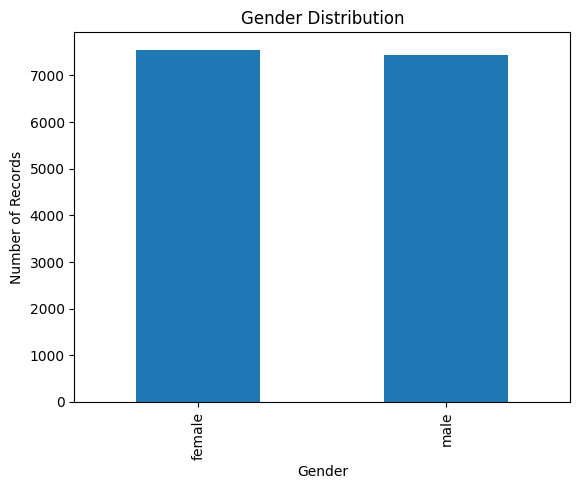

In [0]:
import matplotlib.pyplot as plt

df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Records")
plt.show()

### Step 17: Analyze the Target Variable

The target variable for our regression problem is `Calories`.

We examine its statistical properties to understand the range and distribution of the values we want the model to predict.

In [0]:
df["Calories"].describe()

count    15000.000000
mean        89.539533
std         62.456978
min          1.000000
25%         35.000000
50%         79.000000
75%        138.000000
max        314.000000
Name: Calories, dtype: float64

### Step 18: Visualize Calories Distribution

A histogram helps us understand how the target variable is distributed across the dataset.

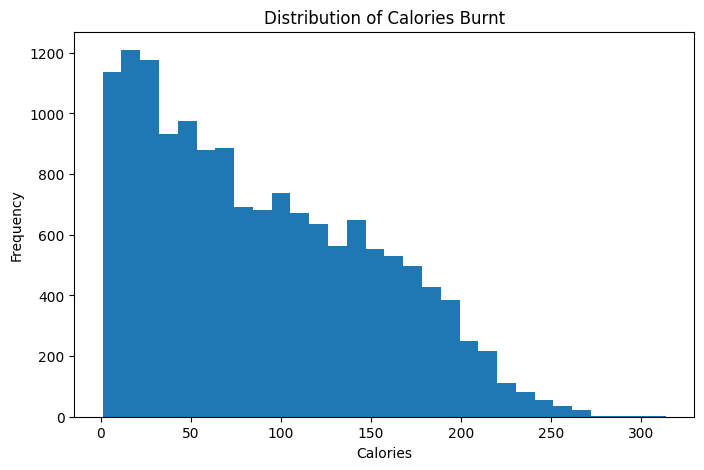

In [0]:
plt.figure(figsize=(8, 5))

plt.hist(df["Calories"], bins=30)

plt.title("Distribution of Calories Burnt")
plt.xlabel("Calories")
plt.ylabel("Frequency")

plt.show()

### Step 19: Analyze Numerical Feature Distributions

We visualize the distributions of the numerical input features.

This can help us identify unusual distributions and potential extreme values that may require further investigation.

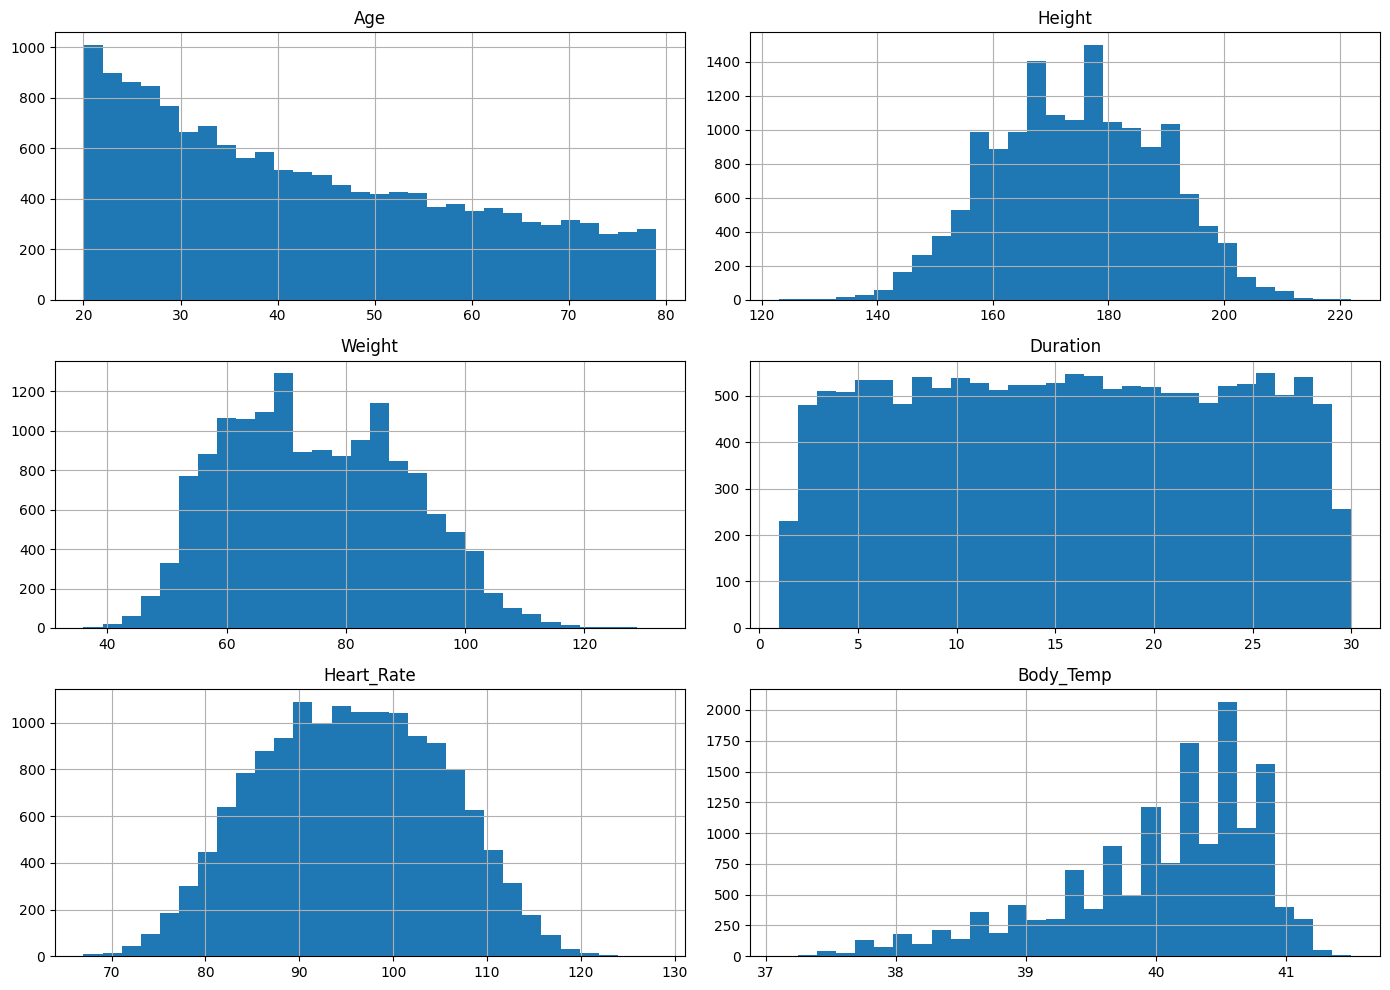

In [0]:
numerical_columns = [
    "Age",
    "Height",
    "Weight",
    "Duration",
    "Heart_Rate",
    "Body_Temp"
]

df[numerical_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

### Step 20: Calculate Feature Correlations

Correlation helps us understand the strength and direction of linear relationships between numerical variables.

We are particularly interested in how each feature is correlated with `Calories`.

In [0]:
correlation_matrix = df[numerical_columns + ["Calories"]].corr()

correlation_matrix

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
Age,1.000000,0.009554,0.090094,0.013247,0.010482,0.013175,0.154395
Height,0.009554,1.000000,0.958451,-0.004625,0.000528,0.001200,0.017537
Weight,0.090094,0.958451,1.000000,-0.001884,0.004311,0.004095,0.035481
Duration,0.013247,-0.004625,-0.001884,1.000000,0.852869,0.903167,0.955421
Heart_Rate,0.010482,0.000528,0.004311,0.852869,1.000000,0.771529,0.897882
Body_Temp,0.013175,0.001200,0.004095,0.903167,0.771529,1.000000,0.824558
Calories,0.154395,0.017537,0.035481,0.955421,0.897882,0.824558,1.000000


### Step 21: Visualize the Correlation Matrix

A heatmap-style visualization makes it easier to identify strong and weak correlations between numerical variables.

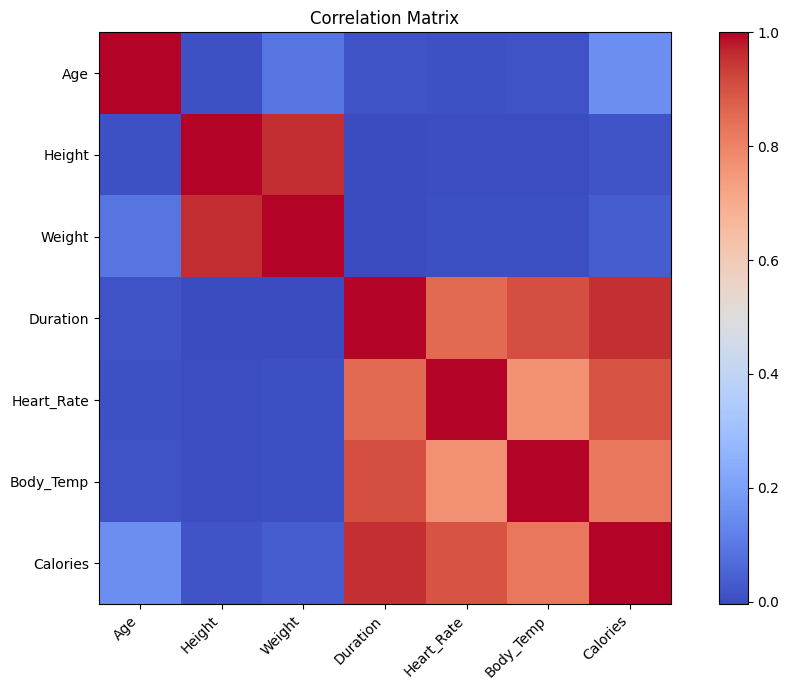

In [0]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

### Step 22: Identify Features Correlated with Calories

We sort the correlation values for `Calories` in descending order.

This allows us to quickly identify which numerical features have the strongest linear relationship with the target variable.

In [0]:
calorie_correlation = (
    correlation_matrix["Calories"]
    .sort_values(ascending=False)
)

calorie_correlation

Calories      1.000000
Duration      0.955421
Heart_Rate    0.897882
Body_Temp     0.824558
Age           0.154395
Weight        0.035481
Height        0.017537
Name: Calories, dtype: float64

### Step 23: Analyze Exercise Duration vs Calories

Exercise duration is an important candidate feature.

We visualize its relationship with calories burnt to determine whether longer exercise sessions are associated with higher calorie expenditure.

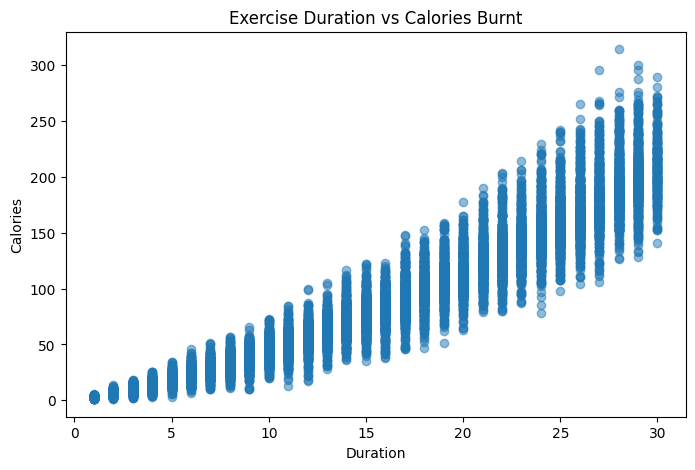

In [0]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Duration"],
    df["Calories"],
    alpha=0.5
)

plt.title("Exercise Duration vs Calories Burnt")
plt.xlabel("Duration")
plt.ylabel("Calories")

plt.show()

### Step 24: Analyze Heart Rate vs Calories

We visualize the relationship between heart rate and calories burnt to determine whether higher heart rates are associated with greater calorie expenditure.

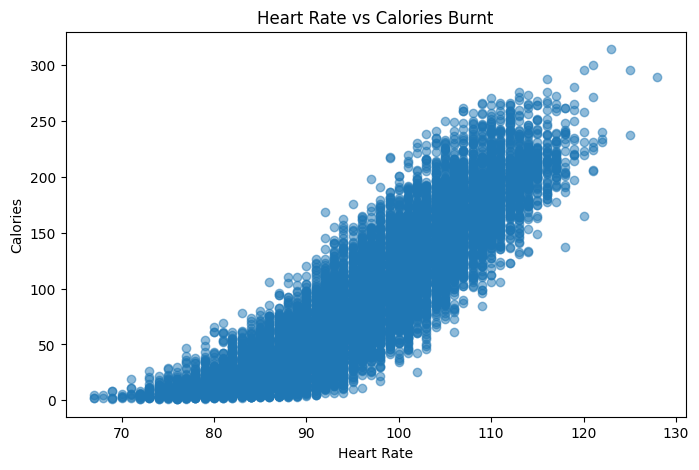

In [0]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Heart_Rate"],
    df["Calories"],
    alpha=0.5
)

plt.title("Heart Rate vs Calories Burnt")
plt.xlabel("Heart Rate")
plt.ylabel("Calories")

plt.show()

### Step 25: Analyze Weight vs Calories

We visualize the relationship between body weight and calories burnt to determine whether weight has a noticeable relationship with the target variable.

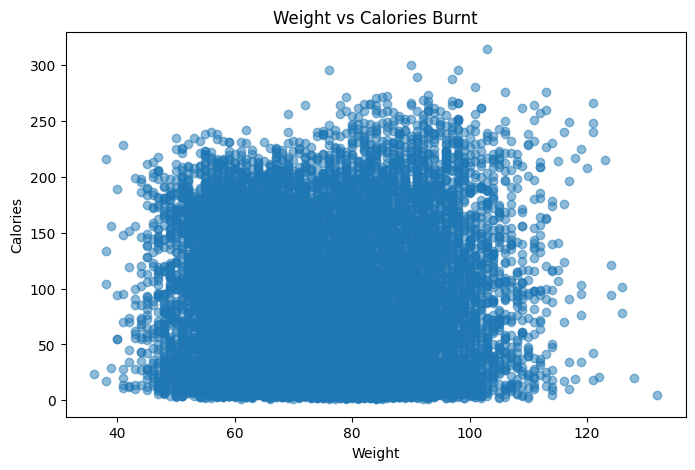

In [0]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Weight"],
    df["Calories"],
    alpha=0.5
)

plt.title("Weight vs Calories Burnt")
plt.xlabel("Weight")
plt.ylabel("Calories")

plt.show()

### Step 26: Detect Potential Outliers

Boxplots can help us identify observations that are unusually far from the rest of the data.

An outlier is not automatically an error. Any potential outlier will be investigated before deciding whether it should be removed.

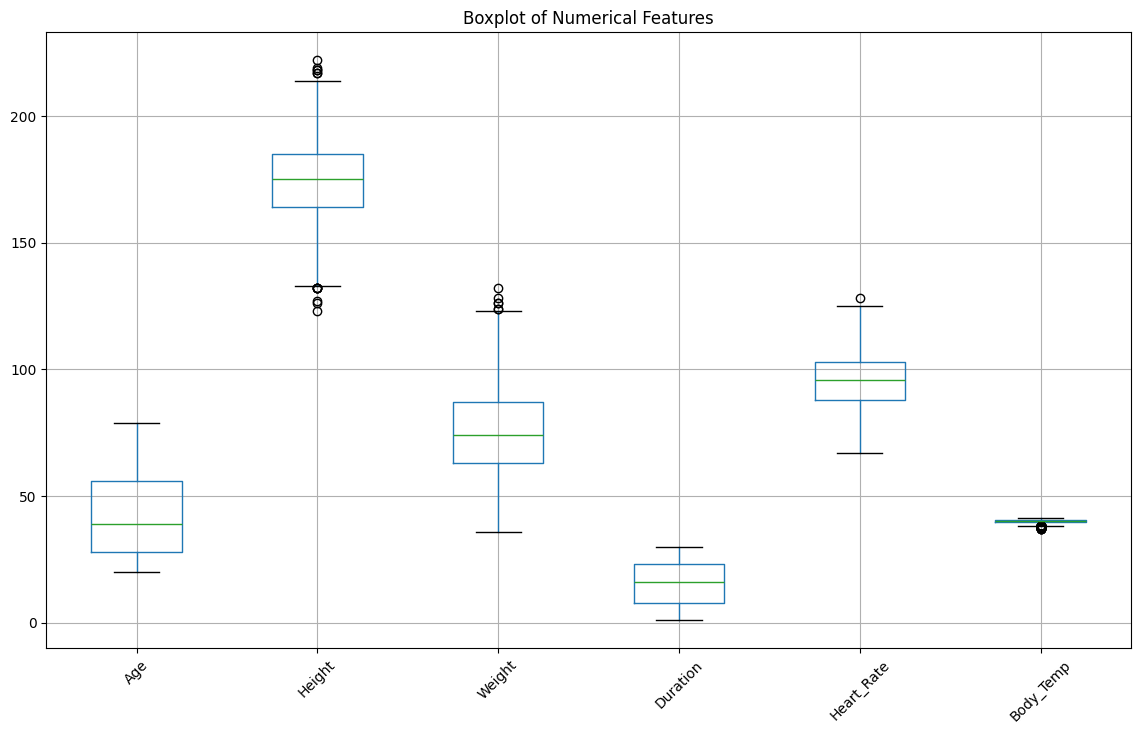

In [0]:
plt.figure(figsize=(14, 8))

df[numerical_columns].boxplot()

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)

plt.show()

### Step 27: Summarize EDA Findings

### Step 27: EDA Findings

The exploratory data analysis provides the following observations:

- `Duration` shows a strong positive relationship with `Calories`.
- `Heart_Rate` shows a strong positive relationship with `Calories`.
- `Body_Temp` also shows a strong positive relationship with `Calories`.
- `Age` has a relatively weak relationship with `Calories`.
- `Height` and `Weight` show comparatively weaker linear relationships with the target.
- Potential outliers are visible in some numerical features, particularly `Height`, `Weight`, `Heart_Rate`, and `Body_Temp`.
- The presence of an outlier does not necessarily indicate an incorrect observation, so the observations will not be removed without further validation.
- `Gender` is a categorical feature and will require encoding before model training.

### Step 28: Define Features and Target

The objective of this project is to predict the number of calories burnt during exercise.

`Calories` is therefore defined as the target variable.

`User_ID` is an identifier and does not provide meaningful predictive information, so it will be excluded from the feature set.

The remaining columns will be used as input features.

In [0]:
# Define the target variable
y = df["Calories"]

# Remove the target and identifier columns from the features
X = df.drop(columns=["Calories", "User_ID"])

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)

Feature columns:
['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

Target column:
Calories


### Step 29: Validate Feature and Target Dimensions

We verify that the feature matrix and target variable contain the same number of observations before proceeding with model development.

In [0]:
print("Features shape :", X.shape)
print("Target shape   :", y.shape)

Features shape : (15000, 7)
Target shape   : (15000,)


### Phase 4: Data Preprocessing and Feature Engineering

Machine learning algorithms require numerical input features.

Our dataset contains one categorical feature, `Gender`, while the remaining features are numerical.

In this phase, we will:

- Encode the categorical feature.
- Separate numerical and categorical features.
- Build a preprocessing pipeline.
- Split the data into training and testing sets.

The preprocessing steps will be fitted only on the training data to prevent data leakage.

### Step 30: Identify Categorical and Numerical Features

We explicitly identify the categorical and numerical columns so that each type of feature can receive the appropriate preprocessing.

In [0]:
categorical_features = ["Gender"]

numerical_features = [
    "Age",
    "Height",
    "Weight",
    "Duration",
    "Heart_Rate",
    "Body_Temp"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Gender']
Numerical features: ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']


### Step 31: Inspect the Gender Values

Before encoding the categorical feature, we check the unique values present in the column.

This ensures that we understand the categories that the preprocessing pipeline needs to handle.

In [0]:
X["Gender"].unique()

array(['male', 'female'], dtype=object)

### Step 32: Split the Dataset into Training and Testing Sets

We split the data before fitting the preprocessing transformations.

The training set will be used to learn the model and preprocessing parameters, while the test set will be reserved for final evaluation.

In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (12000, 7)
X_test : (3000, 7)
y_train: (12000,)
y_test : (3000,)


### Step 33: Create the Preprocessing Pipeline

We use `ColumnTransformer` to apply different transformations to different types of features.

`OneHotEncoder` converts the categorical `Gender` column into numerical columns.

Numerical features are passed through unchanged because tree-based models such as Random Forest and XGBoost do not require feature scaling.

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

### Step 34: Fit the Preprocessing Pipeline on Training Data

The preprocessing pipeline is fitted using only the training data.

This is important because information from the test set must not influence the preprocessing process.

This prevents data leakage.

In [0]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Gender']),
                                ('numerical', 'passthrough',
                                 ['Age', 'Height', 'Weight', 'Duration',
                                  'Heart_Rate', 'Body_Temp'])])

### Step 35: Transform Training and Testing Data

After fitting the preprocessing pipeline on the training data, we transform both the training and testing datasets using the same fitted transformer.

In [0]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape :", X_test_processed.shape)

Processed X_train shape: (12000, 8)
Processed X_test shape : (3000, 8)


### Step 36: Verify the Processed Features

We inspect the feature names generated by the preprocessing pipeline.

This allows us to verify exactly what will be provided to the machine learning model.

In [0]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['categorical__Gender_female' 'categorical__Gender_male' 'numerical__Age'
 'numerical__Height' 'numerical__Weight' 'numerical__Duration'
 'numerical__Heart_Rate' 'numerical__Body_Temp']


### Phase 5: Model Development

In this phase, we build the first machine learning model for predicting calories burnt.

We will combine the preprocessing stage and the XGBoost regression model into a single pipeline.

The pipeline will ensure that the same preprocessing logic used during training is automatically applied when making predictions on new data.

### Step 37: Import the XGBoost Regressor

XGBoost is a gradient boosting algorithm that can be used for regression problems.

We will use `XGBRegressor` because our target variable, `Calories`, is continuous.

In [0]:
from xgboost import XGBRegressor

### Step 38: Create the XGBoost Model

We create our first XGBoost regression model using a simple set of hyperparameters.

These values will serve as our baseline configuration. Later, we will experiment with different hyperparameters and use MLflow to compare the results.

In [0]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

### Step 39: Create the Complete ML Pipeline

We combine the preprocessing component and the XGBoost model into a single scikit-learn pipeline.

This ensures that preprocessing and prediction are treated as one complete workflow.

In [0]:
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

### Step 40: Train the Model

We train the complete pipeline using the training dataset.

The preprocessing transformation is fitted as part of the pipeline using only the training data.

In [0]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender']),
                                                 ('numerical', 'passthrough',
                                                  ['Age', 'Height', 'Weight',
                                                   'Duration', 'Heart_Rate',
                                                   'Body_Temp'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

### Step 41: Generate Predictions

We use the trained pipeline to generate predictions for the test dataset.

The pipeline automatically performs the required preprocessing before passing the data to XGBoost.

In [0]:
y_pred = model_pipeline.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[173.03766  192.59041   51.692772 160.78862  222.13774  177.18025
  97.153     44.299015  79.36707   59.061832]


### Step 42: Evaluate the Model

We evaluate the model using three regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics provide different perspectives on model performance.

In [0]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.1589
RMSE : 1.6728
R²   : 0.9993


### Step 43: Visualize Actual vs Predicted Values

A scatter plot allows us to visually compare the actual calorie values with the values predicted by the model.

A model with strong predictive performance should produce predictions that are generally close to the actual values.

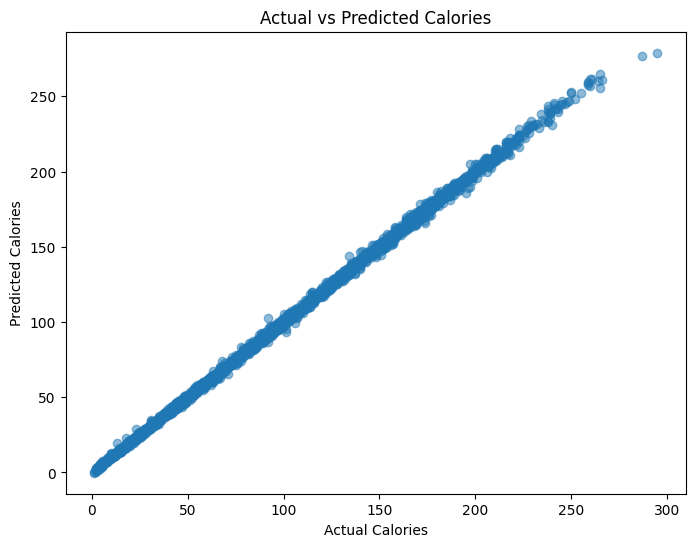

In [0]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")

plt.show()

### Step 44: Analyze Prediction Errors

We calculate the prediction error for each test observation.

The residual is the difference between the actual value and the predicted value.

In [0]:
residuals = y_test - y_pred

print("Mean residual:", residuals.mean())
print("Minimum residual:", residuals.min())
print("Maximum residual:", residuals.max())

Mean residual: 0.0014549103764196238
Minimum residual: -10.903694152832031
Maximum residual: 16.043975830078125


### Step 45: Visualize Prediction Errors

We visualize the distribution of residuals to understand how the model's prediction errors are distributed.

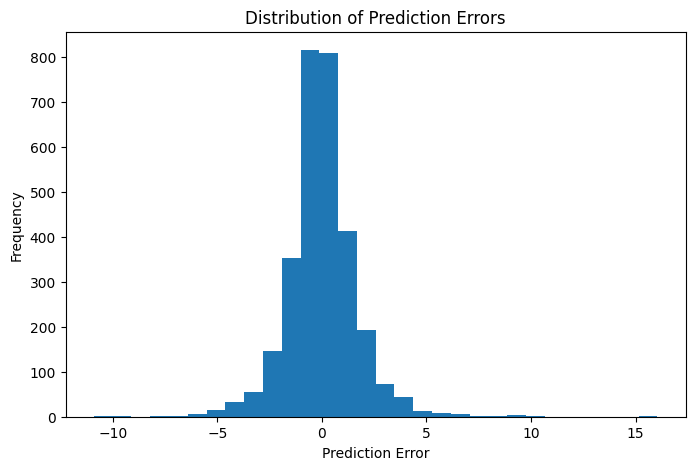

In [0]:
plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

### Phase 5: Model Comparison

In this phase, we train multiple regression algorithms using the same training and testing datasets.

The purpose is to determine which algorithm provides the best predictive performance for the Calories Burnt prediction problem.

All models will use the same preprocessing pipeline and the same train-test split so that their performance can be compared fairly.

The models we will evaluate are:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. XGBoost Regressor

### Step 46: Import the Regression Algorithms

We import the five regression algorithms that will be evaluated.

In [0]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

### Step 47: Create the Model Definitions

We create the five models using reasonable baseline hyperparameters.

At this stage, we are not performing hyperparameter tuning. The goal is to compare the baseline performance of different algorithms.

In [0]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
}

### Step 48: Train and Evaluate All Models

Each model will be placed inside the same preprocessing pipeline.

For every model, we will:

- Apply the preprocessing pipeline.
- Train the model on the training data.
- Generate predictions on the test data.
- Calculate MAE.
- Calculate RMSE.
- Calculate R².
- Store the results for comparison.

In [0]:
from sklearn.base import clone

results = []
trained_models = {}

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    predictions = pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    # Store results
    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    # Store trained pipeline
    trained_models[model_name] = pipeline

### Step 49: Create the Model Comparison Table

We convert the evaluation results into a DataFrame so that the performance of all models can be compared easily.

In [0]:
results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,8.441514,11.488940,0.967294
1,Decision Tree,3.966900,5.826559,0.991588
2,Random Forest,2.280912,3.387063,0.997157
3,Gradient Boosting,1.367169,1.946678,0.999061
4,XGBoost,1.158857,1.672760,0.999307


### Step 50: Sort Models by MAE

MAE represents the average absolute difference between the actual and predicted calorie values.

Since lower MAE indicates smaller prediction errors, we sort the models from best to worst based on MAE.

In [0]:
results_df = results_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2
0,XGBoost,1.158857,1.672760,0.999307
1,Gradient Boosting,1.367169,1.946678,0.999061
2,Random Forest,2.280912,3.387063,0.997157
3,Decision Tree,3.966900,5.826559,0.991588
4,Linear Regression,8.441514,11.488940,0.967294


### Step 51: Sort Models by RMSE

RMSE gives greater weight to larger prediction errors.

We use it as a secondary metric when comparing the models.

In [0]:
results_df.sort_values(
    by="RMSE",
    ascending=True
)

,Model,MAE,RMSE,R2
0,XGBoost,1.158857,1.672760,0.999307
1,Gradient Boosting,1.367169,1.946678,0.999061
2,Random Forest,2.280912,3.387063,0.997157
3,Decision Tree,3.966900,5.826559,0.991588
4,Linear Regression,8.441514,11.488940,0.967294


### Step 52: Compare Models Using R²

R² measures how much of the variation in the target variable is explained by the model.

Higher R² indicates better performance.

In [0]:
results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
0,XGBoost,1.158857,1.672760,0.999307
1,Gradient Boosting,1.367169,1.946678,0.999061
2,Random Forest,2.280912,3.387063,0.997157
3,Decision Tree,3.966900,5.826559,0.991588
4,Linear Regression,8.441514,11.488940,0.967294


### Step 53: Visualize Model Performance

We visualize the MAE of the five models to make the performance comparison easier to interpret.

Lower MAE indicates better performance.

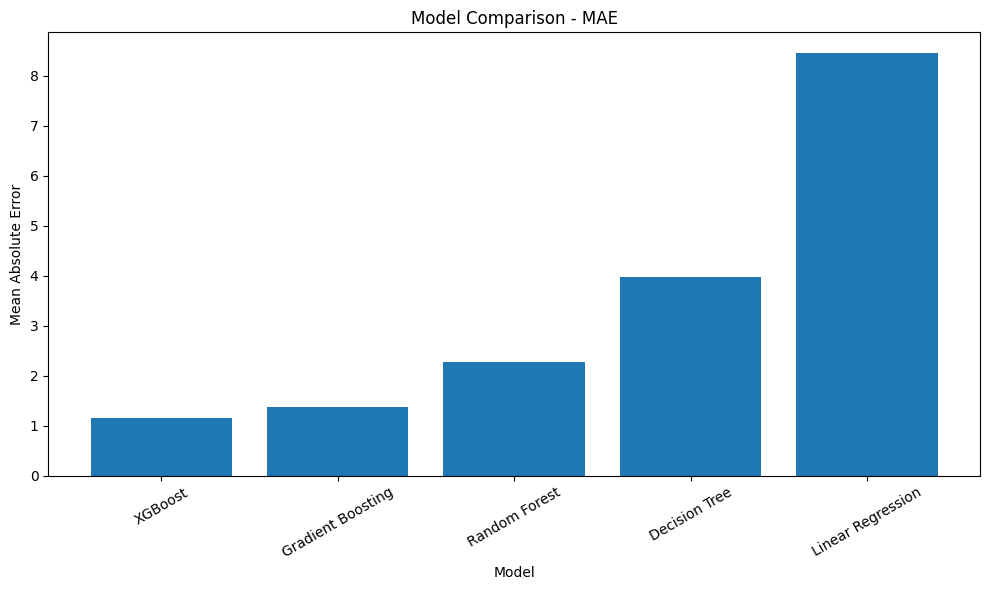

In [0]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Step 54: Select the Best Model

The model with the lowest MAE is selected as the initial candidate for deployment.

RMSE and R² will also be considered to ensure that the model does not have unusually large errors or poor overall explanatory performance.

In [0]:
best_model_name = results_df.loc[0, "Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

print("\nPerformance:")
print(results_df.iloc[0])

Best Model: XGBoost

Performance:
Model     XGBoost
MAE      1.158857
RMSE      1.67276
R2       0.999307
Name: 0, dtype: object


### Step 55: Display the Final Model Comparison

The final comparison table provides a consolidated view of all models evaluated during this experiment.

In [0]:
results_df

,Model,MAE,RMSE,R2
0,XGBoost,1.158857,1.672760,0.999307
1,Gradient Boosting,1.367169,1.946678,0.999061
2,Random Forest,2.280912,3.387063,0.997157
3,Decision Tree,3.966900,5.826559,0.991588
4,Linear Regression,8.441514,11.488940,0.967294


### Step 56: Interpret Model Comparison

Five regression models were trained and evaluated using the same training and testing datasets.

XGBoost achieved the best overall performance:

- MAE: 1.158857
- RMSE: 1.672760
- R²: 0.999307

XGBoost achieved the lowest MAE and RMSE and the highest R² among all evaluated models.

Therefore, XGBoost is selected as the candidate model for the next stage of the MLOps workflow.

The remaining models will not be discarded. Their evaluation results will be tracked as part of the experiment history.

In [0]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print("Selected Model:", best_model_name)

Selected Model: XGBoost


### Step 57: Import MLflow

MLflow is used to track machine learning experiments.

In this phase, we will use MLflow to record the parameters, metrics, and trained models for each of our five experiments.

In [0]:
import mlflow

### Step 58: Check MLflow Version

We check the installed MLflow version to confirm that MLflow is available in our Databricks compute environment.

In [0]:
print("MLflow version:", mlflow.__version__)

MLflow version: 3.0.1


### Step 59: Identify the Current Notebook Path

MLflow experiments in Databricks can be organized using workspace paths.

We retrieve the current notebook path so that our MLflow experiment can be created in the same project area.

In [0]:
notebook_path = (
    dbutils.notebook.entry_point
    .getDbutils()
    .notebook()
    .getContext()
    .notebookPath()
    .get()
)

print(notebook_path)

/Users/sohail_mohd0@outlook.com/Calories_Burnt_MLOps/notebook


### Step 60: Define the MLflow Experiment Path

We create a dedicated MLflow Experiment inside our `Calories_Burnt_MLOps` project.

The experiment will contain the five model training runs that we will compare.

The experiment path is derived from the current notebook path to avoid hardcoding the user workspace path.

In [0]:
experiment_path = notebook_path.rsplit("/", 1)[0] + "/MLflow_Experiment"

print("MLflow Experiment Path:")
print(experiment_path)

MLflow Experiment Path:
/Users/sohail_mohd0@outlook.com/Calories_Burnt_MLOps/MLflow_Experiment


### Step 61: Create the MLflow Experiment

We create a dedicated MLflow Experiment for the Calories Burnt Prediction project.

All model training runs performed in this phase will be associated with this experiment.

In [0]:
mlflow.set_experiment(experiment_path)

print("MLflow experiment configured successfully.")

MLflow experiment configured successfully.


### Step 62: Verify the MLflow Experiment

We verify that MLflow is configured to use the experiment created for this project.

In [0]:
print("Experiment:", experiment_path)

Experiment: /Users/sohail_mohd0@outlook.com/Calories_Burnt_MLOps/MLflow_Experiment


### Step 63: Track the Linear Regression Experiment

We start an MLflow run for the Linear Regression model.

An MLflow run represents one execution of a machine learning experiment.

During this run, we will record:
- Model parameters
- Evaluation metrics
- The trained model

In [0]:
with mlflow.start_run(run_name="Linear_Regression"):

    # Create the model
    linear_model = LinearRegression()

    # Create the complete pipeline
    linear_pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", linear_model)
        ]
    )

    # Train the model
    linear_pipeline.fit(X_train, y_train)

    # Generate predictions
    linear_predictions = linear_pipeline.predict(X_test)

    # Calculate metrics
    linear_mae = mean_absolute_error(y_test, linear_predictions)
    linear_rmse = np.sqrt(
        mean_squared_error(y_test, linear_predictions)
    )
    linear_r2 = r2_score(y_test, linear_predictions)

    # Log metrics
    mlflow.log_metric("MAE", linear_mae)
    mlflow.log_metric("RMSE", linear_rmse)
    mlflow.log_metric("R2", linear_r2)

    # Log the model
    mlflow.sklearn.log_model(
        linear_pipeline,
        name="linear_regression_model"
    )

    print("Linear Regression")
    print(f"MAE  : {linear_mae:.4f}")
    print(f"RMSE : {linear_rmse:.4f}")
    print(f"R2   : {linear_r2:.4f}")

🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-1f9debbc866e4ba89d5012d590950d5d?o=7405608020357355
2026/08/08 17:39:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Linear Regression
MAE  : 8.4415
RMSE : 11.4889
R2   : 0.9673


### Step 64: Define Models and Their Hyperparameters

We define the five candidate regression models along with their relevant hyperparameters.

These configurations will be used to train and track each model as a separate MLflow run.

The parameters will be logged to MLflow so that we can later understand exactly how each model was trained.

In [0]:
mlflow_models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },

    "Decision Tree": {
        "model": DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        ),
        "params": {
            "max_depth": 10,
            "random_state": 42
        }
    },

    "Random Forest": {
        "model": RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": 200,
            "max_depth": 10,
            "random_state": 42
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ),
        "params": {
            "n_estimators": 200,
            "learning_rate": 0.05,
            "max_depth": 5,
            "random_state": 42
        }
    },

    "XGBoost": {
        "model": XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        ),
        "params": {
            "n_estimators": 200,
            "learning_rate": 0.05,
            "max_depth": 6,
            "random_state": 42
        }
    }
}

### Step 65: Track All Five Models with MLflow

Each model is trained inside its own MLflow run.

For every run, we:

1. Create the preprocessing and model pipeline.
2. Log the model parameters.
3. Train the model.
4. Generate predictions.
5. Calculate MAE, RMSE, and R².
6. Log the evaluation metrics.
7. Log the trained model.

This creates a reproducible experiment history containing one run for each candidate model.

In [0]:
mlflow_results = []

for model_name, model_info in mlflow_models.items():

    with mlflow.start_run(run_name=model_name.replace(" ", "_")):

        model = model_info["model"]
        params = model_info["params"]

        # Create pipeline
        pipeline = Pipeline(
            steps=[
                ("preprocessor", clone(preprocessor)),
                ("model", model)
            ]
        )

        # Log parameters
        if params:
            mlflow.log_params(params)

        mlflow.log_param("algorithm", model_name)

        # Train
        pipeline.fit(X_train, y_train)

        # Predict
        predictions = pipeline.predict(X_test)

        # Calculate metrics
        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        r2 = r2_score(y_test, predictions)

        # Log metrics
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)

        # Log model
        mlflow.sklearn.log_model(
            pipeline,
            name="model"
        )

        # Save result locally for comparison
        mlflow_results.append({
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        print(f"{model_name} completed")

🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-e2aef6fc76ff4578b2effc022b0dd86e?o=7405608020357355
2026/08/08 17:39:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Linear Regression completed


🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-8a27a9cc3cd942b6b84a15087628f9c5?o=7405608020357355
2026/08/08 17:39:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Decision Tree completed


🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-0babc6c1d10a49e6b3642f2dfa32c8ff?o=7405608020357355
2026/08/08 17:39:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Random Forest completed


🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-dafa3833d48c4b1c9edefe9e9eb6318b?o=7405608020357355
2026/08/08 17:39:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Gradient Boosting completed


🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-4dc700a02d2a4d32bdf64a121221167f?o=7405608020357355
2026/08/08 17:39:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost completed


### Step 66: Create a Model Input Example

A model input example provides MLflow with a representative example of the data expected by the trained model.

MLflow can use this example to infer and store the model's input and output signature.

The input example will use a single row from the original feature dataset.

In [0]:
input_example = X_train.iloc[[0]]

input_example

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
9839,male,37,179.0,77.0,7.0,81.0,39.5


### Step 67: Generate the MLflow Model Signature

The model signature describes the expected inputs and outputs of the machine learning model.

This provides a clear contract between the deployed model and applications that will consume it.

In [0]:
from mlflow.models import infer_signature

signature = infer_signature(
    X_train,
    linear_pipeline.predict(X_train)
)

signature

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


inputs: 
  ['Gender': string (required), 'Age': long (required), 'Height': double (required), 'Weight': double (required), 'Duration': double (required), 'Heart_Rate': double (required), 'Body_Temp': double (required)]
outputs: 
  [Tensor('float64', (-1,))]
params: 
  None

### Step 69: Track All Five Models with Signatures

We retrain the five candidate models and log each experiment to MLflow.

For every run, we record:

- Model algorithm
- Hyperparameters
- MAE
- RMSE
- R²
- Input example
- Model signature
- Trained model

The model signature and input example allow MLflow and downstream serving systems to understand the expected input and output structure of the model.

In [0]:
mlflow_results_v2 = []

for model_name, model_info in mlflow_models.items():

    with mlflow.start_run(
        run_name=f"{model_name.replace(' ', '_')}_v2"
    ):

        model = model_info["model"]
        params = model_info["params"]

        # Create preprocessing + model pipeline
        pipeline = Pipeline(
            steps=[
                ("preprocessor", clone(preprocessor)),
                ("model", model)
            ]
        )

        # Log algorithm
        mlflow.log_param("algorithm", model_name)

        # Log model hyperparameters
        if params:
            mlflow.log_params(params)

        # Train
        pipeline.fit(X_train, y_train)

        # Predictions
        predictions = pipeline.predict(X_test)

        # Metrics
        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        r2 = r2_score(y_test, predictions)

        # Log metrics
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)

        # Create model signature
        signature = infer_signature(
            X_train,
            pipeline.predict(X_train)
        )

        # Log model with signature and input example
        mlflow.sklearn.log_model(
            pipeline,
            name="model",
            signature=signature,
            input_example=input_example
        )

        # Store results for comparison
        mlflow_results_v2.append({
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        print(f"{model_name} completed")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-d56d5378d9174d57b75fdb514c990635?o=7405608020357355


Linear Regression completed


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-2cb0bafad95341ca89c29a97c9a3527f?o=7405608020357355


Decision Tree completed


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-f60fe5b09fe948388d1185b7f393d939?o=7405608020357355


Random Forest completed


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-282af24fdc944e72b4b8c38326f80d6c?o=7405608020357355


Gradient Boosting completed


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://adb-7405608020357355.15.azuredatabricks.net/ml/experiments/512481940259715/models/m-f0d70ae765d44b29ab180b2dfc52d6ef?o=7405608020357355


XGBoost completed


### Step 70: Compare the MLflow Experiment Results

The metrics from the five MLflow runs are collected into a DataFrame and sorted by MAE.

This allows us to verify that the MLflow-tracked experiments produce the same model ranking as our original model comparison.

In [0]:
mlflow_results_v2_df = pd.DataFrame(mlflow_results_v2)

mlflow_results_v2_df = mlflow_results_v2_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

mlflow_results_v2_df

,Model,MAE,RMSE,R2
0,XGBoost,1.158857,1.672760,0.999307
1,Gradient Boosting,1.367169,1.946678,0.999061
2,Random Forest,2.280912,3.387063,0.997157
3,Decision Tree,3.966900,5.826559,0.991588
4,Linear Regression,8.441514,11.488940,0.967294


### Step 71: Select the Best MLflow Model

The model with the lowest MAE is selected as the candidate model for the Model Registry.

RMSE and R² are also considered to confirm that the selected model performs well across multiple evaluation metrics.

In [0]:
best_mlflow_model = mlflow_results_v2_df.iloc[0]

print("Selected Model:", best_mlflow_model["Model"])
print(f"MAE : {best_mlflow_model['MAE']:.4f}")
print(f"RMSE: {best_mlflow_model['RMSE']:.4f}")
print(f"R2  : {best_mlflow_model['R2']:.4f}")

Selected Model: XGBoost
MAE : 1.1589
RMSE: 1.6728
R2  : 0.9993


### Step 72: Verify the MLflow Experiment

The MLflow Experiment should now contain the model runs created during experimentation.

The improved runs contain:

- Parameters
- Metrics
- Model
- Input example
- Model signature

These tracked experiments will provide the evidence used to select a model for registration.

### Step 73: Configure Unity Catalog Model Registry

MLflow 3 uses Unity Catalog as the model registry.

We explicitly configure the registry URI so that our model will be registered in Unity Catalog.


In [0]:
import mlflow

mlflow.set_registry_uri("databricks-uc")

print("Registry URI:", mlflow.get_registry_uri())

Registry URI: databricks-uc


### Step 74: Define the Registered Model Name

We define the name that will be used for our production model in Unity Catalog.

The model name follows the three-level Unity Catalog namespace:

catalog.schema.model

In [0]:
CATALOG_NAME = "databricks00"
SCHEMA_NAME = "default"
MODEL_NAME = "calories_burnt_predictor"

registered_model_name = (
    f"{CATALOG_NAME}.{SCHEMA_NAME}.{MODEL_NAME}"
)

print("Registered model name:")
print(registered_model_name)

Registered model name:
databricks00.default.calories_burnt_predictor


### Step 75: Verify Unity Catalog Access

We verify that the selected catalog and schema are accessible before attempting to register the model.

In [0]:
spark.sql(f"USE CATALOG {CATALOG_NAME}")
spark.sql(f"USE SCHEMA {SCHEMA_NAME}")

print("Catalog:", CATALOG_NAME)
print("Schema :", SCHEMA_NAME)

Catalog: databricks00
Schema : default


### Step 76: Retrieve the XGBoost_v2 MLflow Run

XGBoost_v2 was selected as our best-performing model.

We retrieve its MLflow run so that we can locate the exact logged model that we want to register.

In [0]:
experiment = mlflow.get_experiment_by_name(experiment_path)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName = 'XGBoost_v2'"
)

xgb_run_id = runs.iloc[0]["run_id"]

print("XGBoost_v2 Run ID:")
print(xgb_run_id)

XGBoost_v2 Run ID:
3e7d45956d9344e9a6fbd7b5e02a0d78


### Step 77: Retrieve the XGBoost Logged Model

We retrieve the MLflow LoggedModel associated with the XGBoost_v2 run.

The LoggedModel represents the packaged model that was created during our MLflow experiment.

In [0]:
logged_models = mlflow.search_logged_models(
    experiment_ids=[experiment.experiment_id]
)

print("Available columns:")
print(logged_models.columns.tolist())

Available columns:
['artifact_location', 'creation_timestamp', 'experiment_id', 'last_updated_timestamp', 'metrics', 'model_id', 'model_type', 'name', 'params', 'source_run_id', 'status', 'status_message', 'tags']


### Step 78: Identify the XGBoost_v2 Logged Model

We filter the LoggedModels returned by MLflow using the `source_run_id` of our XGBoost_v2 experiment run.

This identifies the exact LoggedModel produced by the XGBoost_v2 run.

In [0]:
xgb_logged_model = logged_models[
    logged_models["source_run_id"] == xgb_run_id
]

xgb_logged_model[
    ["model_id", "name", "source_run_id", "status"]
]

,model_id,name,source_run_id,status
0,m-f0d70ae765d44b29ab180b2dfc52d6ef,model,3e7d45956d9344e9a6fbd7b5e02a0d78,READY


### Step 79: Extract the Logged Model ID

We extract the unique LoggedModel ID of XGBoost_v2.

This ID will be used as the source when registering the model in Unity Catalog.

In [0]:
xgb_model_id = xgb_logged_model.iloc[0]["model_id"]

print("XGBoost Logged Model ID:")
print(xgb_model_id)

XGBoost Logged Model ID:
m-f0d70ae765d44b29ab180b2dfc52d6ef


In [0]:
xgb_logged_model[
    ["model_id", "name", "source_run_id", "status"]
]

,model_id,name,source_run_id,status
0,m-f0d70ae765d44b29ab180b2dfc52d6ef,model,3e7d45956d9344e9a6fbd7b5e02a0d78,READY


### Step 80: Register the XGBoost Model in Unity Catalog

The XGBoost_v2 model was selected as the best-performing model during our MLflow experiment.

The LoggedModel is in the `READY` state, so we can now register it in Unity Catalog.

Registering the model gives it a persistent name and version that can be used throughout the remaining MLOps lifecycle.

In [0]:
model_uri = f"models:/{xgb_model_id}"

registered_model = mlflow.register_model(
    model_uri,
    registered_model_name
)

print("Registered Model:")
print(registered_model)

Registered model 'databricks00.default.calories_burnt_predictor' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '2' of model 'databricks00.default.calories_burnt_predictor': https://adb-7405608020357355.15.azuredatabricks.net/explore/data/models/databricks00/default/calories_burnt_predictor/version/2?o=7405608020357355


Registered Model:
<ModelVersion: aliases=[], creation_timestamp=1786211660210, current_stage=None, deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1786211662685, metrics=[<Metric: dataset_digest='', dataset_name='', key='MAE', model_id='m-f0d70ae765d44b29ab180b2dfc52d6ef', run_id='3e7d45956d9344e9a6fbd7b5e02a0d78', step=0, timestamp=1786210826115, value=1.1588570271519323>,
 <Metric: dataset_digest='', dataset_name='', key='R2', model_id='m-f0d70ae765d44b29ab180b2dfc52d6ef', run_id='3e7d45956d9344e9a6fbd7b5e02a0d78', step=0, timestamp=1786210826723, value=0.9993066719570708>,
 <Metric: dataset_digest='', dataset_name='', key='RMSE', model_id='m-f0d70ae765d44b29ab180b2dfc52d6ef', run_id='3e7d45956d9344e9a6fbd7b5e02a0d78', step=0, timestamp=1786210826451, value=1.6727604151969475>], model_id='m

### Step 81: Verify the Registered Model

The model has been registered in Unity Catalog.

We now retrieve the available versions of the registered model to verify that Version 1 was created successfully.

In [0]:
from mlflow import MlflowClient

client = MlflowClient()

model_versions = client.search_model_versions(
    filter_string=f"name='{registered_model_name}'"
)

for version in model_versions:
    print("Model Name :", version.name)
    print("Version    :", version.version)
    print("Status     :", version.status)
    print("Source     :", version.source)
    print("Run ID     :", version.run_id)
    print("-" * 60)

Model Name : databricks00.default.calories_burnt_predictor
Version    : 2
Status     : READY
Source     : models:/m-f0d70ae765d44b29ab180b2dfc52d6ef
Run ID     : 3e7d45956d9344e9a6fbd7b5e02a0d78
------------------------------------------------------------
Model Name : databricks00.default.calories_burnt_predictor
Version    : 1
Status     : READY
Source     : models:/m-1d028d9edc294edea29ab6efd723a7bc
Run ID     : 00a78a15805d4a9ab5d5639fae2dab82
------------------------------------------------------------


### Step 82: Retrieve Model Version 1

We retrieve Version 1 of the registered model.

This version represents the XGBoost model that we selected based on our MLflow experiment results.

In [0]:
model_version = client.get_model_version(
    name=registered_model_name,
    version="1"
)

print("Model Name :", model_version.name)
print("Version    :", model_version.version)
print("Status     :", model_version.status)
print("Source     :", model_version.source)

Model Name : databricks00.default.calories_burnt_predictor
Version    : 1
Status     : READY
Source     : models:/m-1d028d9edc294edea29ab6efd723a7bc


### Step 83: Document the Registered Model

We add a description to the registered model so that anyone viewing the model in Unity Catalog can understand its purpose and origin.

In [0]:
client.update_registered_model(
    name=registered_model_name,
    description=(
        "XGBoost regression model for predicting calories burnt "
        "during exercise. Selected from five candidate regression "
        "models using MAE, RMSE, and R2 evaluation metrics. "
        "Tracked using MLflow and registered in Unity Catalog."
    )
)

print("Model description updated successfully.")

Model description updated successfully.


### Step 84: Add Metadata to Model Version 1

We add metadata to Version 1 to document why this particular model version was selected.

In [0]:
client.set_model_version_tag(
    name=registered_model_name,
    version="1",
    key="model_type",
    value="XGBoost"
)

client.set_model_version_tag(
    name=registered_model_name,
    version="1",
    key="selection_reason",
    value="Best performance among five evaluated regression models"
)

client.set_model_version_tag(
    name=registered_model_name,
    version="1",
    key="experiment",
    value="Calories_Burnt_MLOps"
)

print("Model version metadata added successfully.")

Model version metadata added successfully.


### Step 85: Define the Production Model URI

The model has been registered in Unity Catalog as `databricks00.default.calories_burnt_predictor`.

Version 1 contains the XGBoost model selected from our MLflow experiment.

We define the model URI that will be used to load this registered version.

In [0]:
production_model_uri = (
    "models:/databricks00.default.calories_burnt_predictor/1"
)

print("Production Model URI:")
print(production_model_uri)

Production Model URI:
models:/databricks00.default.calories_burnt_predictor/1


### Step 86: Load the Registered Model

We load Version 1 of the registered model from Unity Catalog using MLflow.

This verifies that the model stored in the registry can be loaded independently of the original training code.

In [0]:
loaded_model = mlflow.pyfunc.load_model(
    production_model_uri
)

print("Registered model loaded successfully.")

Registered model loaded successfully.


### Step 87: Create a Sample Prediction Request

We create a sample input containing the features required by the registered model.

This simulates a new exercise record arriving after the model has been deployed.

In [0]:
sample_input = pd.DataFrame({
    "Gender": ["male"],
    "Age": [25],
    "Height": [175],
    "Weight": [70],
    "Duration": [30],
    "Heart_Rate": [120],
    "Body_Temp": [39.0]
})

sample_input

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,male,25,175,70,30,120,39.0


### Step 88: Create a Schema-Compatible Prediction Request

The registered model contains an MLflow model signature that expects several numerical features as floating-point values.

We therefore construct the prediction request using the data types defined by the model signature.

In [0]:
sample_input = pd.DataFrame({
    "Gender": ["male"],
    "Age": [25],
    "Height": [175.0],
    "Weight": [70.0],
    "Duration": [30.0],
    "Heart_Rate": [120.0],
    "Body_Temp": [39.0]
})

print(sample_input)
print("\nData types:")
print(sample_input.dtypes)

  Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0   male   25   175.0    70.0      30.0       120.0       39.0

Data types:
Gender         object
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
dtype: object


### Step 89: Generate a Prediction Using the Registered Model

We pass the schema-compatible input to Version 1 of the registered model.

The model will automatically perform the preprocessing and generate the predicted calories burnt.

In [0]:
prediction = loaded_model.predict(sample_input)

print("Predicted Calories Burnt:", prediction[0])

Predicted Calories Burnt: 233.57025


### Step 90: Understand the Model Serving Endpoint

A Model Serving endpoint provides a real-time interface for our registered machine learning model.

Instead of loading the model manually using Python, an application can send a prediction request to the endpoint.

The endpoint will:

1. Receive the input data.
2. Validate the input against the model signature.
3. Execute the registered model.
4. Return the predicted calories burnt.

### Step 91: Define the Model Serving Endpoint

We define a unique name for the serving endpoint.

The endpoint will serve Version 1 of our registered `calories_burnt_predictor` model.

In [0]:
endpoint_name = "calories-burnt-predictor"

print("Serving endpoint:", endpoint_name)

Serving endpoint: calories-burnt-predictor


### Step 92: Create the Model Serving Endpoint

We create a real-time Model Serving endpoint for the registered model.

The endpoint will use Version 1 of `databricks00.default.calories_burnt_predictor`.

### Step 93: Understand the Model Serving Endpoint

The registered XGBoost model is now deployed as a real-time serving endpoint.

The endpoint accepts prediction requests and returns predictions from Version 1 of the registered model.

This separates model inference from the training notebook.

### Step 94: Identify the Model Serving Endpoint URL

The serving endpoint is now ready.

The endpoint exposes an HTTP API that applications can use to send prediction requests to our deployed model.

We will use this URL to communicate with the deployed XGBoost model.


### Step 95: Send a Prediction Request to the Serving Endpoint

We send a new exercise record to the deployed model through its REST API.

The request contains the features expected by the model signature.

This tests whether our deployed model can perform real-time inference.

### Step 96: Verify the Prediction Response

The serving endpoint should return the prediction generated by Version 1 of the registered XGBoost model.

The returned value represents the predicted number of calories burnt for the supplied exercise record.

### Step 97: Compare Endpoint and Local Model Predictions

We compare the prediction returned by the deployed serving endpoint with the prediction previously generated by loading the registered model directly with MLflow.

This verifies that the deployed endpoint is serving the same model version that we tested locally.

In [0]:
local_prediction = loaded_model.predict(sample_input)[0]

endpoint_prediction = 233.57042646484375

print("Local Model Prediction    :", local_prediction)
print("Serving Endpoint Prediction:", endpoint_prediction)
print("Difference                :", abs(
    local_prediction - endpoint_prediction
))

Local Model Prediction    : 233.57025
Serving Endpoint Prediction: 233.57042646484376
Difference                : 0.00016784668


### Step 98: Test Multiple Prediction Inputs

We test the deployed model with multiple exercise records rather than relying on a single prediction.

This helps verify that the serving endpoint can handle different input values and consistently return predictions.

test1

{
  "dataframe_records": [
    {
      "Gender": "male",
      "Age": 25,
      "Height": 175.0,
      "Weight": 70.0,
      "Duration": 30.0,
      "Heart_Rate": 120.0,
      "Body_Temp": 39.0
    }
  ]
}

test 2
{
  "dataframe_records": [
    {
      "Gender": "female",
      "Age": 30,
      "Height": 165.0,
      "Weight": 60.0,
      "Duration": 45.0,
      "Heart_Rate": 135.0,
      "Body_Temp": 38.5
    }
  ]
}

test 3
{
  "dataframe_records": [
    {
      "Gender": "male",
      "Age": 40,
      "Height": 180.0,
      "Weight": 85.0,
      "Duration": 60.0,
      "Heart_Rate": 145.0,
      "Body_Temp": 39.2
    }
  ]
}